#### Final Evaluation Analysis

In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [9]:
data_path = "training_results/iso_sparsity_summary.csv"
df = pd.read_csv(data_path, encoding="utf-8")

# Rename columns for better readability
df.rename(
    columns={
        "Method": "method",
        "Primary Metric": "metric",
        "Target Channel Sparsity (%)": "target_channel_sparsity",
        "Target Weight Sparsity (%)": "target_weight_sparsity",
        "Test Top-1 (%)": "test_top_1_acc",
        "Lambda (mean+/-std)": "lambda",
        "Weight Sparsity (%)": "weight_sparsity",
        "Channel Sparsity (%)": "channel_sparsity",
    },
    inplace=True,
)

# Filter the DataFrame for the two methods of interest
soft_thresholding_df = df[df["method"] == "Soft_Thresholding_Conv"].copy()
block_soft_thresholding_df = df[df["method"] == "Block_Soft_Thresholding_Conv"].copy()

# Drop the columns that are not needed for the analysis
soft_thresholding_df.drop(columns=["method", "metric", "target_channel_sparsity"], inplace=True)
block_soft_thresholding_df.drop(columns=["method", "metric", "target_weight_sparsity"], inplace=True)

# Extract valuable information from the columns
soft_thresholding_df["test_top_1_acc"] = (
    soft_thresholding_df["test_top_1_acc"].str.split("+/", regex=False).str[0].astype(float)
)

soft_thresholding_df["lambda"] = (
    soft_thresholding_df["lambda"].str.split("+/", regex=False).str[0].astype(float)
)


block_soft_thresholding_df["test_top_1_acc"] = (
    block_soft_thresholding_df["test_top_1_acc"].str.split("+/", regex=False).str[0].astype(float)
)

block_soft_thresholding_df["lambda"] = (
    block_soft_thresholding_df["lambda"].str.split("+/", regex=False).str[0].astype(float)
)

# Order the DataFrame columns for better readability
soft_thresholding_df = soft_thresholding_df[["target_weight_sparsity","test_top_1_acc", "weight_sparsity", "channel_sparsity", "lambda"]]
block_soft_thresholding_df = block_soft_thresholding_df[["target_channel_sparsity", "test_top_1_acc", "weight_sparsity", "channel_sparsity", "lambda"]]


print("The following table shows the mean results for the Soft Thresholding method (Target Metric: Weight Sparsity):")
display(soft_thresholding_df)
print("The following table shows the mean results for the Block Soft Thresholding method (Target Metric: Channel Sparsity):")
display(block_soft_thresholding_df)


The following table shows the mean results for the Soft Thresholding method (Target Metric: Weight Sparsity):


,target_weight_sparsity,test_top_1_acc,weight_sparsity,channel_sparsity,lambda
0,0.0,88.9167,0.00,0.00,0.00000
1,25.0,89.8200,22.34,7.99,0.00060
2,50.0,89.2633,47.18,22.29,0.00115
3,75.0,86.7467,71.85,40.99,0.00237
4,90.0,82.4900,87.72,61.77,0.00628


The following table shows the mean results for the Block Soft Thresholding method (Target Metric: Channel Sparsity):


,target_channel_sparsity,test_top_1_acc,weight_sparsity,channel_sparsity,lambda
5,0.0,88.9167,0.00,0.00,0.00000
6,25.0,89.2433,30.07,26.79,0.01921
7,50.0,88.2667,52.91,49.31,0.03670
8,75.0,84.8833,79.13,74.11,0.17783
9,90.0,78.2467,94.18,92.96,0.32313


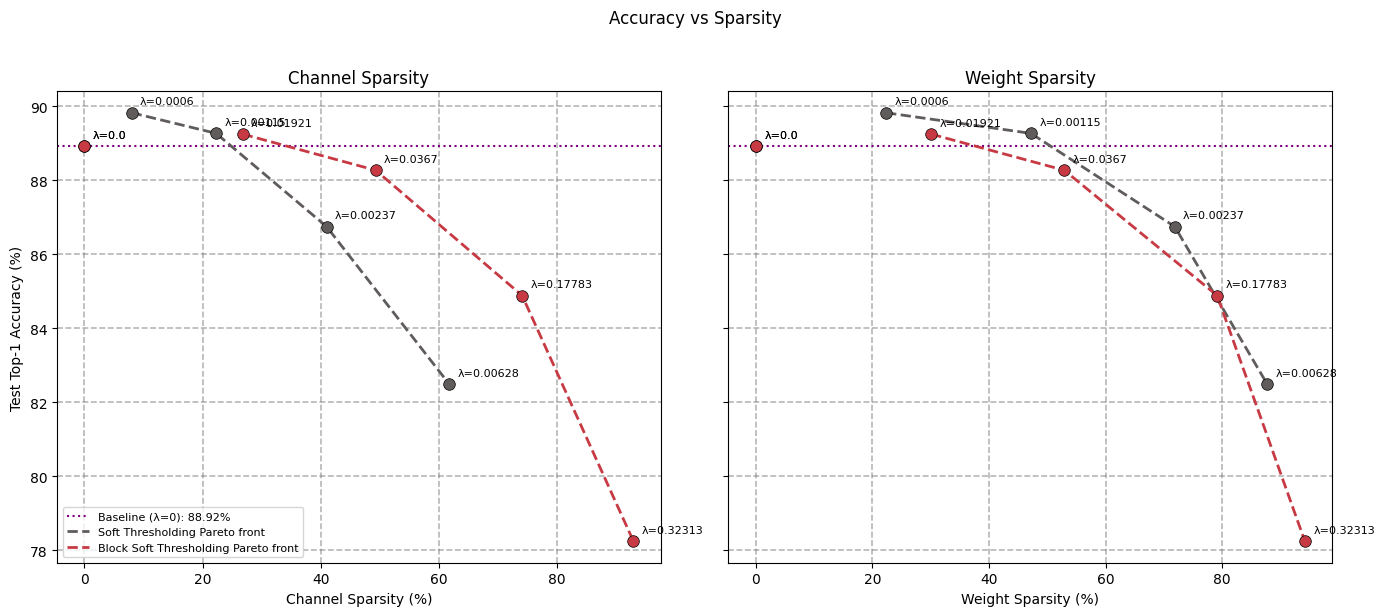

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Keep your original Pareto frontier logic intact
def pareto_frontier(sparsity, accuracy):
    order = np.argsort(-np.asarray(sparsity))
    s, a = np.asarray(sparsity)[order], np.asarray(accuracy)[order]
    keep = []
    best_acc = -np.inf
    for i in range(len(s)):
        if a[i] > best_acc:
            keep.append(i)
            best_acc = a[i]
    front_s, front_a = s[keep], a[keep]
    re_order = np.argsort(front_s)
    return front_s[re_order], front_a[re_order]

# 2. Map your new DataFrames and choose colors
methods = {
    "Soft Thresholding":       (soft_thresholding_df, "#615C5C"),
    "Block Soft Thresholding": (block_soft_thresholding_df, "#C73A43"),
}

# 3. Align with your new column names
sparsity_cols = ["channel_sparsity", "weight_sparsity"]

# 4. Dynamically find the baseline accuracy where lambda == 0.0
# Looks for lambda == 0.0 in either dataframe to establish the baseline
try:
    baseline_acc = soft_thresholding_df.loc[soft_thresholding_df["lambda"] == 0.0, "test_top_1_acc"].iloc[0]
except IndexError:
    # Fallback to the other dataframe if lambda=0 isn't in the first one
    baseline_acc = block_soft_thresholding_df.loc[block_soft_thresholding_df["lambda"] == 0.0, "test_top_1_acc"].iloc[0]

# 5. Build the subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, col in zip(axes, sparsity_cols):
    # Plot baseline
    ax.axhline(baseline_acc, color="purple", linestyle=":", linewidth=1.5,
               label=f"Baseline (λ=0): {baseline_acc:.2f}%", zorder=1)

    for name, (data, color) in methods.items():
        s = data[col].values
        a = data["test_top_1_acc"].values  # Updated column name
        
        # Scatter plot
        ax.scatter(s, a, color=color, edgecolor="black", linewidth=0.5,
                   s=70, zorder=3)

        # Annotations using updated "lambda" column name
        for lam, sx, ay in zip(data["lambda"], s, a):
            ax.annotate(f"λ={lam}", (sx, ay), textcoords="offset points",
                        xytext=(6, 6), fontsize=8, color="black")

        # Pareto Front Line
        fs, fa = pareto_frontier(s, a)
        ax.plot(fs, fa, color=color, linestyle="--", linewidth=2,
                label=f"{name} Pareto front", zorder=2)

    # Human-readable titles based on column names
    clean_title = col.replace("_", " ").title()
    ax.set_xlabel(f"{clean_title} (%)")
    ax.set_title(clean_title)
    ax.grid(True, color="gray", linestyle="--", linewidth=1.15, alpha=0.6)
    ax.set_axisbelow(True)

# 6. Global styling
axes[0].set_ylabel("Test Top-1 Accuracy (%)")
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Accuracy vs Sparsity", y=1.02)
plt.tight_layout()
plt.show()

#### Training Dynamics

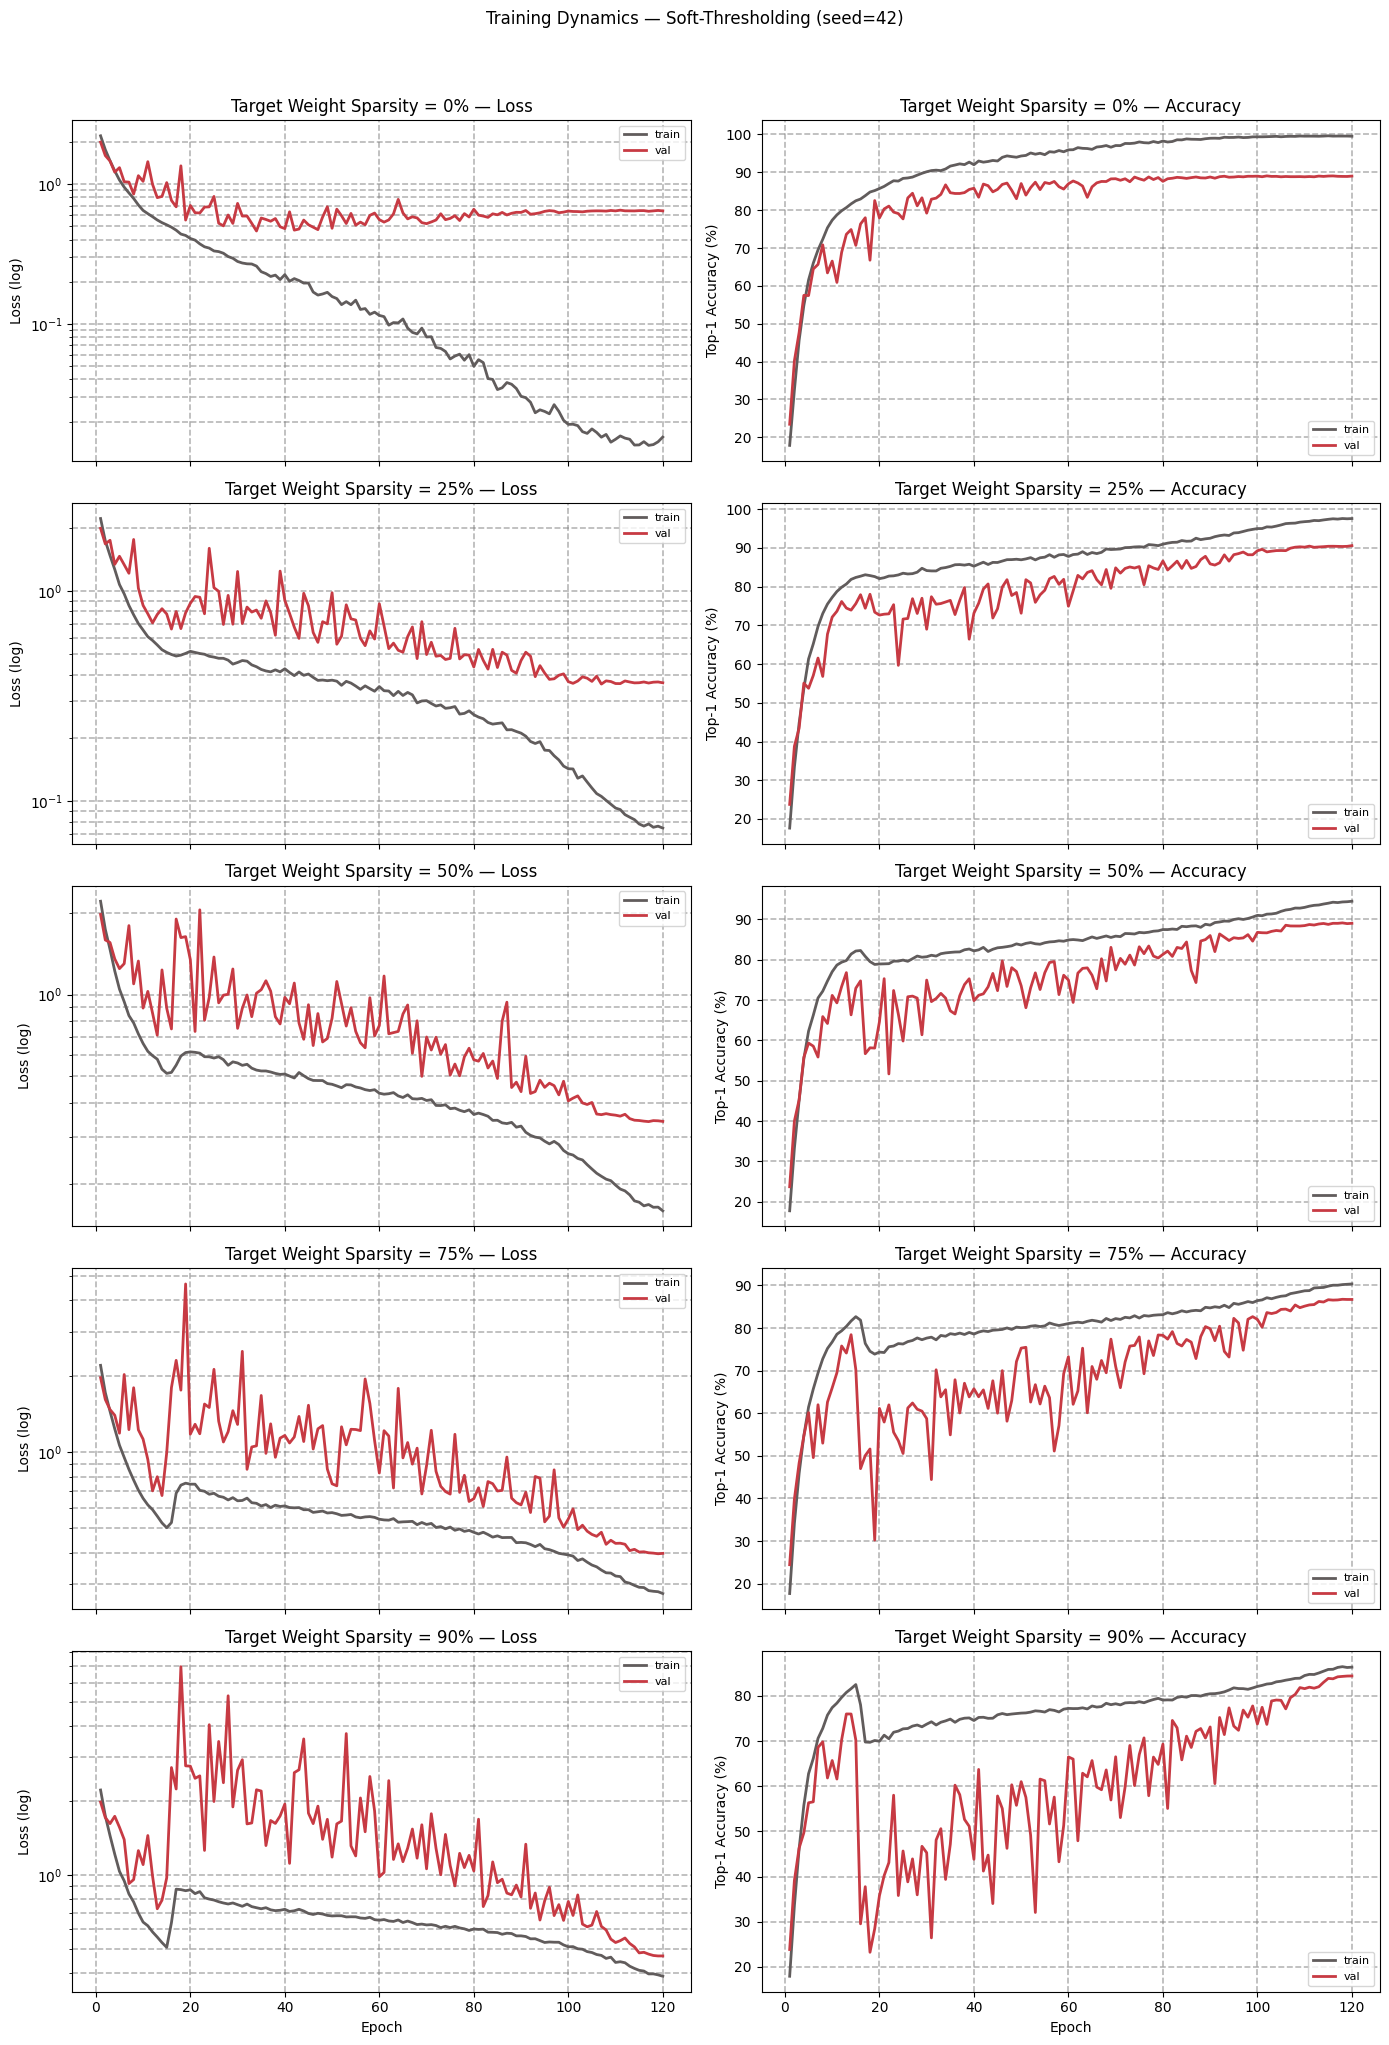

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Colors — reuse the two-tone palette from the Pareto plot
TRAIN_COLOR = "#615C5C"
VAL_COLOR   = "#C73A43"


def plot_training_dynamics(method, target_label, seed=42,
                           targets=(0, 25, 50, 75, 90),
                           history_dir="training_results", display=None):
    """
    Plot a 5x2 grid of per-epoch training dynamics for one method/seed:
    one row per sparsity target, left column = loss (log y), right = accuracy.

    `target_label` names the method's natural target metric so the titles read
    correctly — "Weight Sparsity" for Soft-Thresholding, "Channel Sparsity" for
    Block Soft-Thresholding. `display` is the friendly name shown in the title;
    `method` (the raw key) still drives the history-CSV filenames.
    """
    display = display or method
    fig, axes = plt.subplots(len(targets), 2, figsize=(14, 4 * len(targets)),
                             sharex=True)

    for row, target in enumerate(targets):
        path = f"{history_dir}/history_{method}_sp{target}_S{seed}.csv"
        h = pd.read_csv(path)

        # Loss subplot (left column, log y-scale)
        ax_loss = axes[row, 0]
        ax_loss.plot(h["epoch"], h["train_loss"], color=TRAIN_COLOR,
                     linewidth=2, label="train", zorder=3)
        ax_loss.plot(h["epoch"], h["val_loss"], color=VAL_COLOR,
                     linewidth=2, label="val", zorder=3)
        ax_loss.set_yscale("log")
        ax_loss.set_ylabel("Loss (log)")
        ax_loss.set_title(f"Target {target_label} = {target}% — Loss")
        ax_loss.grid(True, which="both", color="gray", linestyle="--",
                     linewidth=1.15, alpha=0.6)
        ax_loss.set_axisbelow(True)
        ax_loss.legend(loc="upper right", fontsize=8)

        # Accuracy subplot (right column)
        ax_acc = axes[row, 1]
        ax_acc.plot(h["epoch"], h["train_top1"], color=TRAIN_COLOR,
                    linewidth=2, label="train", zorder=3)
        ax_acc.plot(h["epoch"], h["val_top1"], color=VAL_COLOR,
                    linewidth=2, label="val", zorder=3)
        ax_acc.set_ylabel("Top-1 Accuracy (%)")
        ax_acc.set_title(f"Target {target_label} = {target}% — Accuracy")
        ax_acc.grid(True, color="gray", linestyle="--", linewidth=1.15,
                    alpha=0.6)
        ax_acc.set_axisbelow(True)
        ax_acc.legend(loc="lower right", fontsize=8)

    # Shared x-label only on the bottom row, global title above
    for ax in axes[-1, :]:
        ax.set_xlabel("Epoch")

    fig.suptitle(f"Training Dynamics — {display} (seed={seed})", y=1.02)
    plt.tight_layout()
    plt.show()


# Soft-Thresholding — natural target metric is weight sparsity
plot_training_dynamics("Soft_Thresholding_Conv", "Weight Sparsity",
                       display="Soft-Thresholding")


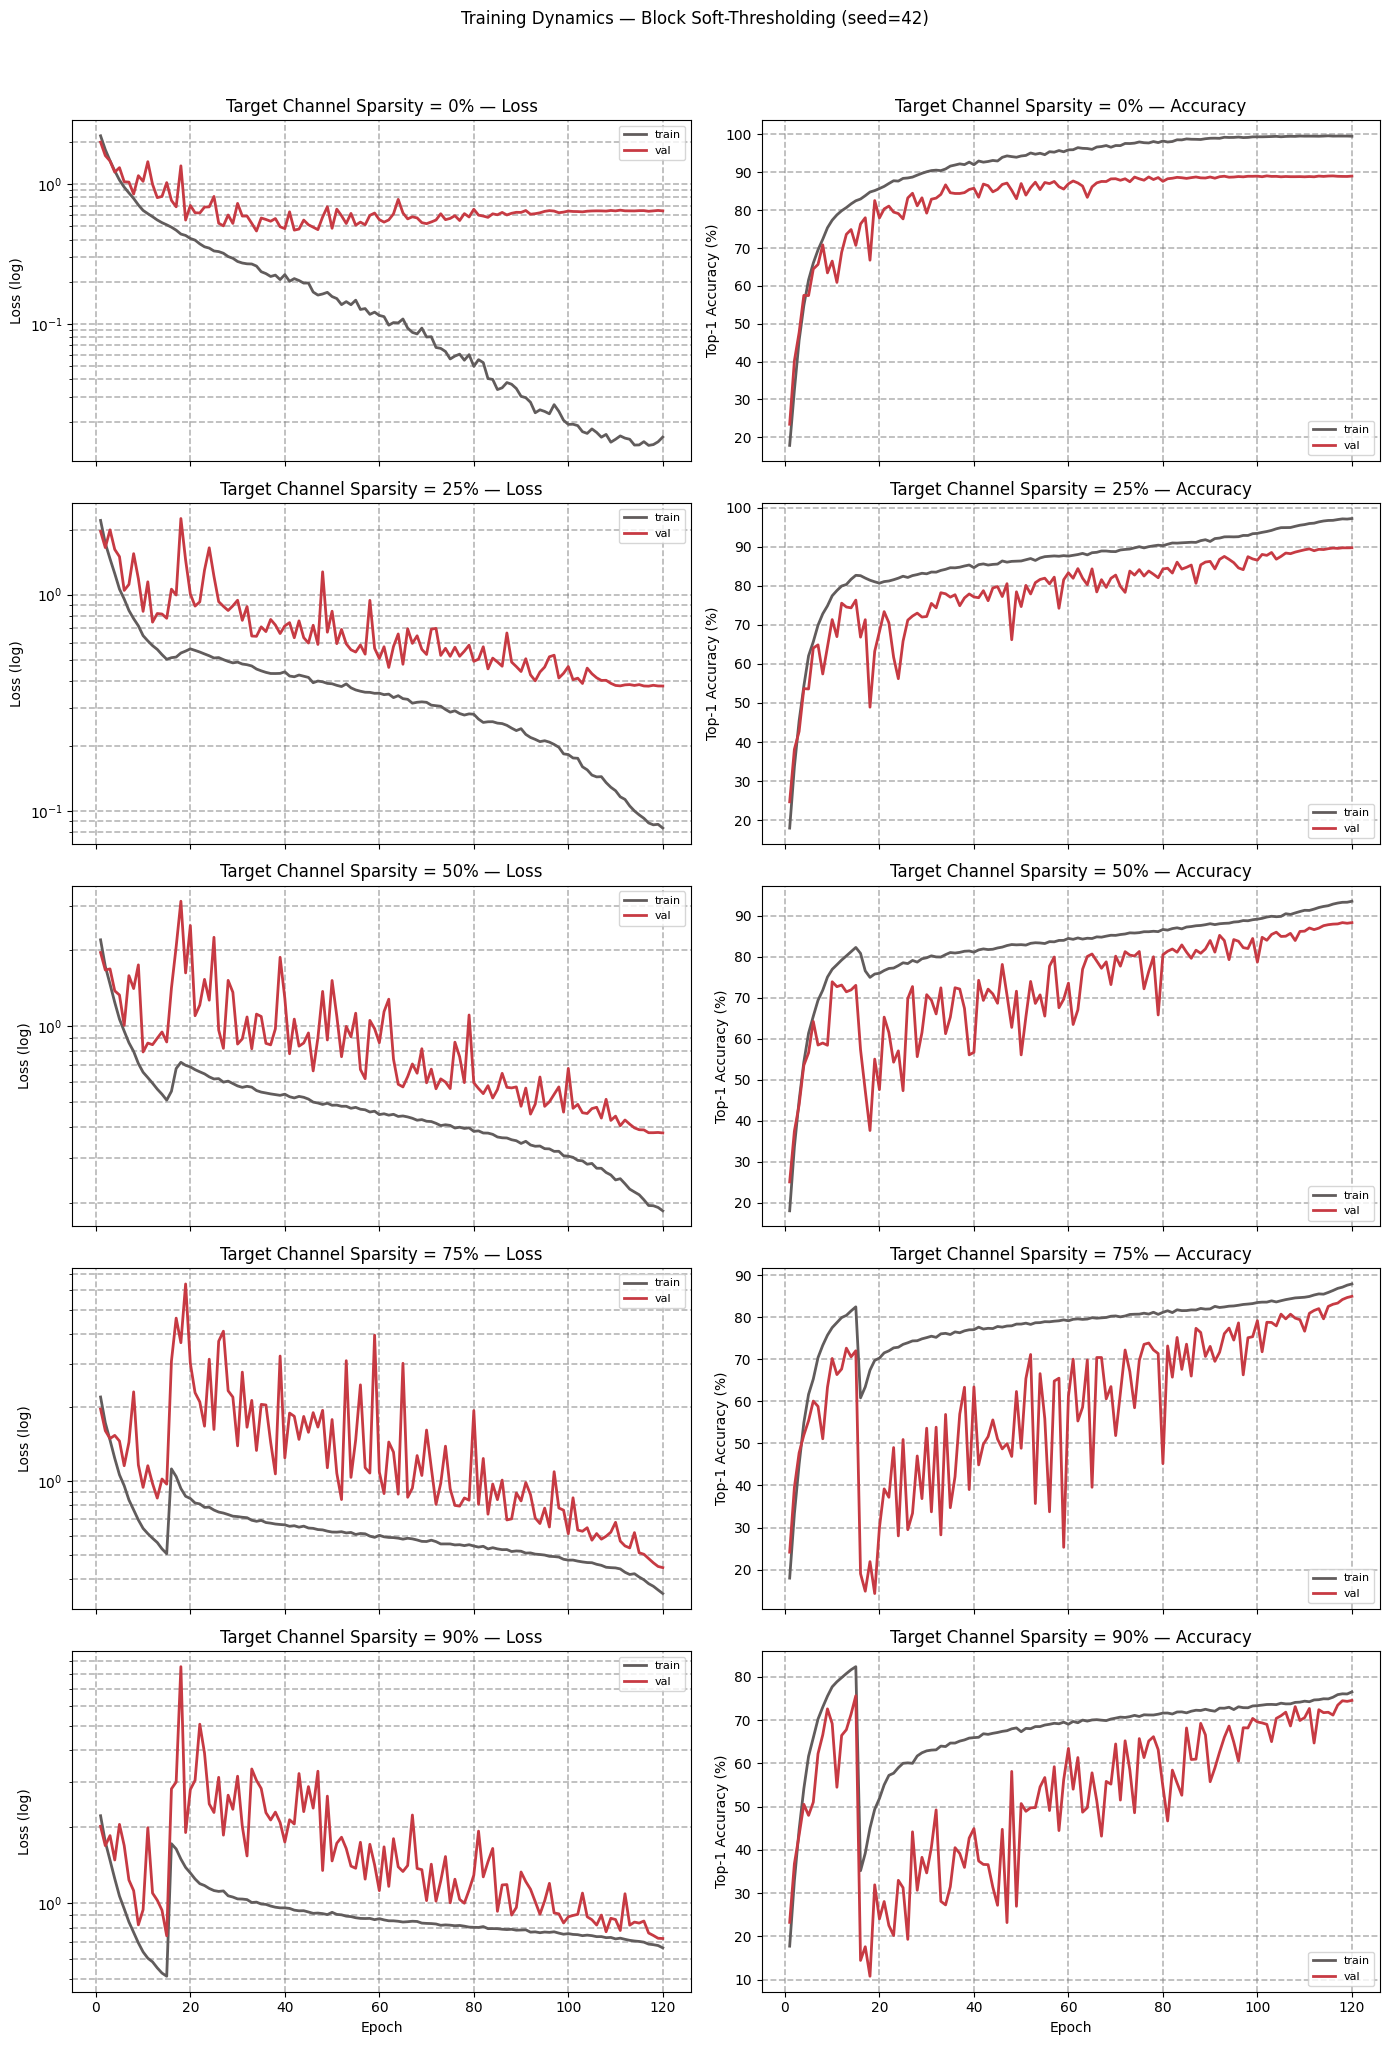

In [12]:
# Block Soft-Thresholding — natural target metric is channel sparsity
plot_training_dynamics("Block_Soft_Thresholding_Conv", "Channel Sparsity",
                       display="Block Soft-Thresholding")


#### Layer Weight Distribution

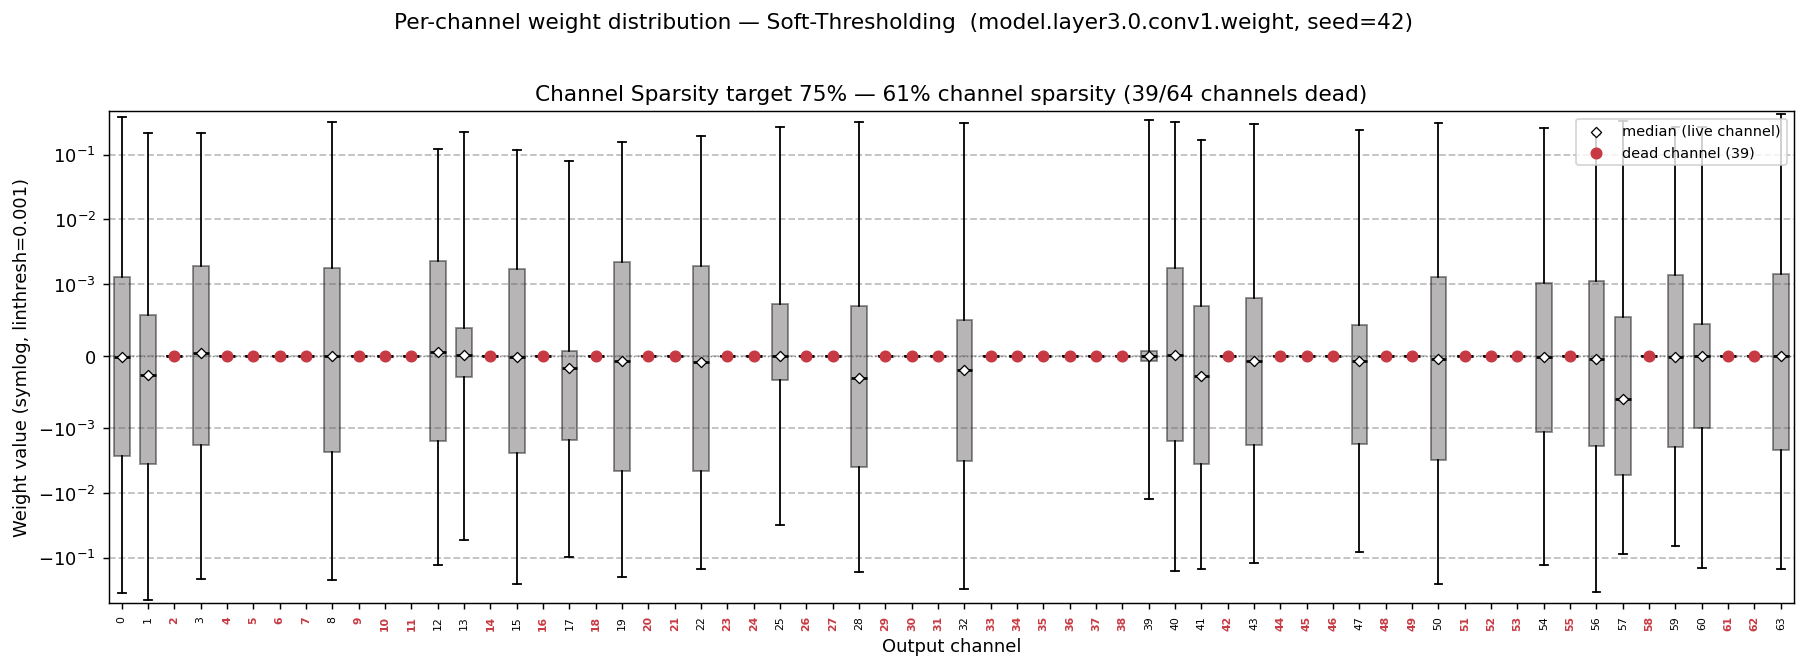

In [15]:
import numpy as np
import torch  # plt/pd already imported above; TRAIN_COLOR/VAL_COLOR reused


def plot_channel_weight_boxplots(
    method, display, label,
    layer="model.layer3.0.conv1.weight", seed=42, target=75,
    history_dir="training_results", linthresh=1e-3, dpi=130,
    headline_metric="weight",
):
    """
    Per-output-channel weight box plots for ONE method on a single conv layer.
    One box per output channel; whiskers span the channel's full min..max so the
    Y extent *is* the value range. Rendered as its own figure (call once per
    method) at higher dpi so the per-channel labels stay sharp.

    `headline_metric` selects the achieved figure shown in the title for THIS
    layer: "weight" -> % of weights == 0, "channel" -> % of fully-dead output
    channels. (`label`/`target` still describe the run's *target* metric, so a
    weight-sparsity-targeted run can be reported by its channel sparsity.)

    The Y axis is symlog (linear within +/-linthresh of zero, logarithmic
    beyond) so the tiny Q1-Q3 boxes near zero AND the few large-magnitude
    survivor whiskers are visible together. Note: symlog spacing is not linear.

    Markers: white diamond -> median (LIVE channels only); red dot + red x-axis
    number -> a fully-dead channel (all weights zero).
    """
    sd = torch.load(f"{history_dir}/model_{method}_sp{target}_S{seed}.pt",
                    map_location="cpu", weights_only=False)["state_dict"]
    w = sd[layer]                        # [out, in, kh, kw]
    flat = w.view(w.shape[0], -1).numpy()
    n_ch = flat.shape[0]
    dead = (flat != 0).sum(axis=1) == 0  # fully-zero output channels
    pct_zero = 100.0 * (w == 0).float().mean().item()          # weight sparsity
    pct_channel = 100.0 * dead.sum() / n_ch                    # channel sparsity

    fig, ax = plt.subplots(figsize=(14, 5), dpi=dpi)

    # One box per output channel; whiskers span full min..max = the range.
    bp = ax.boxplot([row for row in flat], whis=(0, 100),
                    showfliers=False, patch_artist=True, widths=0.6)
    # Color dead channels (degenerate box at 0) distinctly from live ones.
    for patch, d in zip(bp["boxes"], dead):
        patch.set_facecolor(VAL_COLOR if d else TRAIN_COLOR)
        patch.set_alpha(0.85 if d else 0.45)
    # Emphasize the median line, then mark it with a diamond -- but ONLY on live
    # channels, so it never overlaps the red dead-channel dots at zero.
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(1.5)
    medians = np.median(flat, axis=1)
    live_idx = [i + 1 for i, d in enumerate(dead) if not d]
    ax.scatter(live_idx, medians[~dead], marker="D", s=16,
               facecolor="white", edgecolor="black", linewidth=0.7,
               zorder=6, label="median (live channel)")
    # Fully-dead channels: a clear red dot on the zero line (and the matching
    # x-axis number is coloured red below) -- distinct from the median marker.
    dead_idx = [i + 1 for i, d in enumerate(dead) if d]
    ax.scatter(dead_idx, [0] * len(dead_idx), color=VAL_COLOR, s=32,
               zorder=7, label=f"dead channel ({len(dead_idx)})")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":", zorder=1)

    # symlog so the small IQR boxes and the large whiskers are both visible.
    ax.set_yscale("symlog", linthresh=linthresh)

    achieved = (f"{pct_channel:.0f}% channel sparsity"
                if headline_metric == "channel"
                else f"{pct_zero:.0f}% weights zero")
    ax.set_title(f"{label} target {target}% — {achieved} "
                 f"({int(dead.sum())}/{n_ch} channels dead)")
    ax.set_xlabel("Output channel")
    ax.set_ylabel(f"Weight value (symlog, linthresh={linthresh:g})")
    # Tight X axis with EVERY channel index labelled; rotated so all numbers fit.
    # Dead channels in red + bold.
    dead_set = set(dead_idx)
    ax.set_xlim(0.5, n_ch + 0.5)
    ax.set_xticks(range(1, n_ch + 1))
    ax.set_xticklabels(range(0, n_ch), rotation=90, fontsize=6)
    for lbl, pos in zip(ax.get_xticklabels(), range(1, n_ch + 1)):
        if pos in dead_set:
            lbl.set_color(VAL_COLOR)
            lbl.set_fontweight("bold")
    ax.grid(True, axis="y", which="both", color="gray", linestyle="--",
            linewidth=1.0, alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right", fontsize=8)

    fig.suptitle(f"Per-channel weight distribution — {display}  "
                 f"({layer}, seed={seed})", y=1.02)
    plt.tight_layout()
    plt.show()


# Soft-Thresholding — targeted on weight sparsity, but reported here by the
# channel sparsity it incidentally produces on this layer.
plot_channel_weight_boxplots("Soft_Thresholding_Conv", "Soft-Thresholding",
                             "Channel Sparsity", headline_metric="channel")


In [ ]:
# Block Soft-Thresholding — natural target metric is channel sparsity
plot_channel_weight_boxplots("Block_Soft_Thresholding_Conv",
                             "Block Soft-Thresholding", "Channel Sparsity",
                             headline_metric="channel")
